In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pypsa


# ============================================================
# 1. Path to solved PyPSA network
# ============================================================

NETWORK_PATH = Path("solved_networks_core/solved/baseline/bat1x_gas24_coal14.2_co2_93_cy2009_dur1x.nc")



In [3]:

# ============================================================
# 2. Load solved network
# ============================================================

print(f"Loading network: {NETWORK_PATH}")

n = pypsa.Network(NETWORK_PATH)

print("Network loaded.")
print(f"Snapshots: {len(n.snapshots)}")



Loading network: solved_networks_core\solved\baseline\bat1x_gas24_coal14.2_co2_93_cy2009_dur1x.nc


INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Network loaded.
Snapshots: 8760


In [4]:

# ============================================================
# 3. Extract hourly DE00 marginal prices
# ============================================================

if "DE00" not in n.buses.index:
    raise KeyError(
        f"DE00 not found in network buses.\n"
        f"Available buses: {n.buses.index.tolist()}"
    )

de_price = n.buses_t.marginal_price["DE00"]

print("\nDE00 price statistics:")
print(f"Mean:   {de_price.mean():.2f} EUR/MWh")
print(f"Median: {de_price.median():.2f} EUR/MWh")
print(f"Min:    {de_price.min():.2f} EUR/MWh")
print(f"Max:    {de_price.max():.2f} EUR/MWh")




DE00 price statistics:
Mean:   59.51 EUR/MWh
Median: 71.12 EUR/MWh
Min:    0.01 EUR/MWh
Max:    3000.00 EUR/MWh


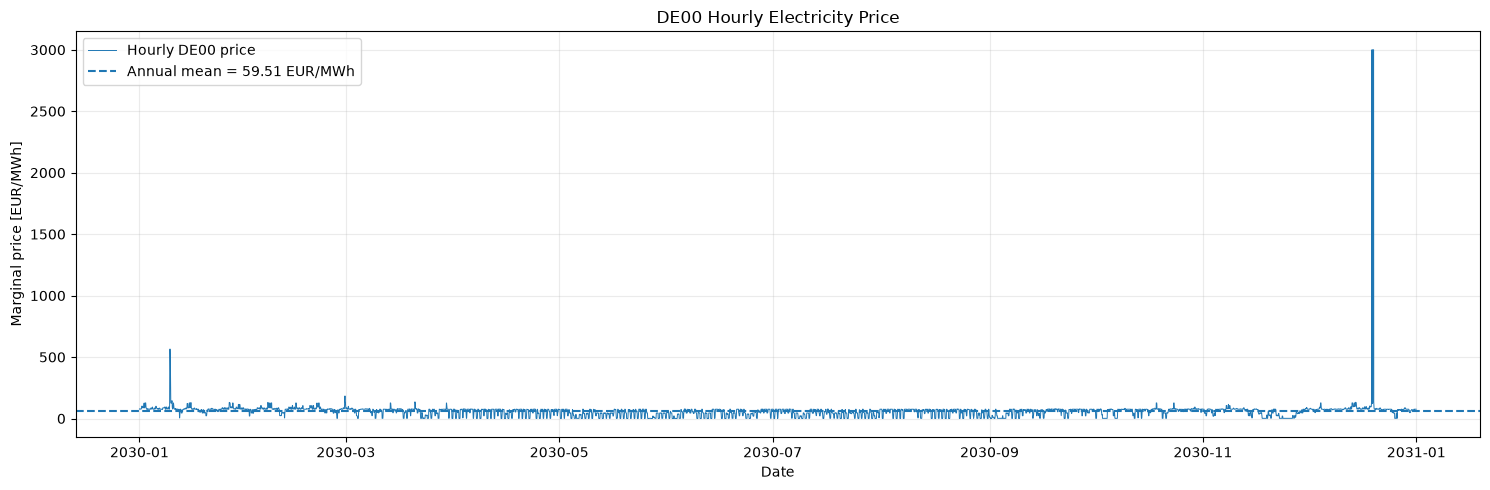

In [5]:

# ============================================================
# 4. Plot full year of hourly prices
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    de_price.index,
    de_price,
    linewidth=0.7,
    label="Hourly DE00 price",
)

ax.axhline(
    de_price.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Annual mean = {de_price.mean():.2f} EUR/MWh",
)

ax.set_title("DE00 Hourly Electricity Price")
ax.set_xlabel("Date")
ax.set_ylabel("Marginal price [EUR/MWh]")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [6]:
CSV_PATH = Path("de00_hourly_prices.csv")
price_df = de_price.rename("price_eur_mwh").to_frame()

price_df.index.name = "timestamp"

price_df.to_csv(CSV_PATH)

print(f"\nSaved hourly prices to: {CSV_PATH}")
print(f"Number of rows: {len(price_df)}")



Saved hourly prices to: de00_hourly_prices.csv
Number of rows: 8760
